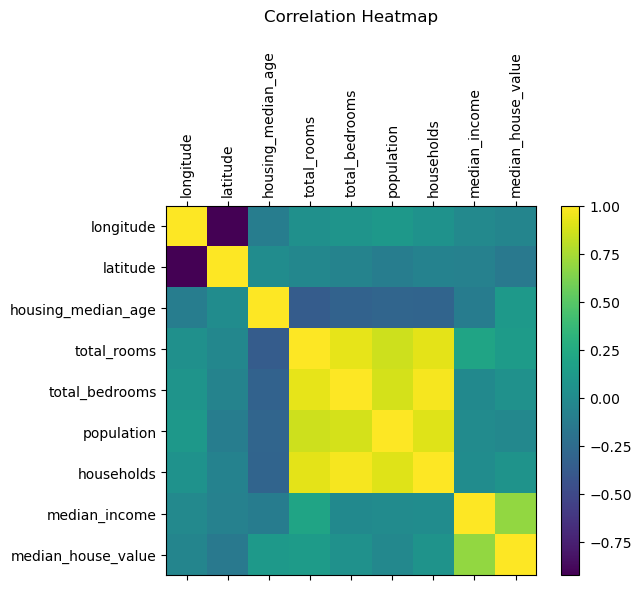

Sample Data:
    median_income  housing_median_age  total_bedrooms  total_rooms  population  \
0         8.3252                41.0           129.0        880.0       322.0   
1         8.3014                21.0          1106.0       7099.0      2401.0   
2         7.2574                52.0           190.0       1467.0       496.0   
3         5.6431                52.0           235.0       1274.0       558.0   
4         3.8462                52.0           280.0       1627.0       565.0   

   households  latitude  longitude  
0       126.0     37.88    -122.23  
1      1138.0     37.86    -122.22  
2       177.0     37.85    -122.24  
3       219.0     37.85    -122.25  
4       259.0     37.85    -122.25  


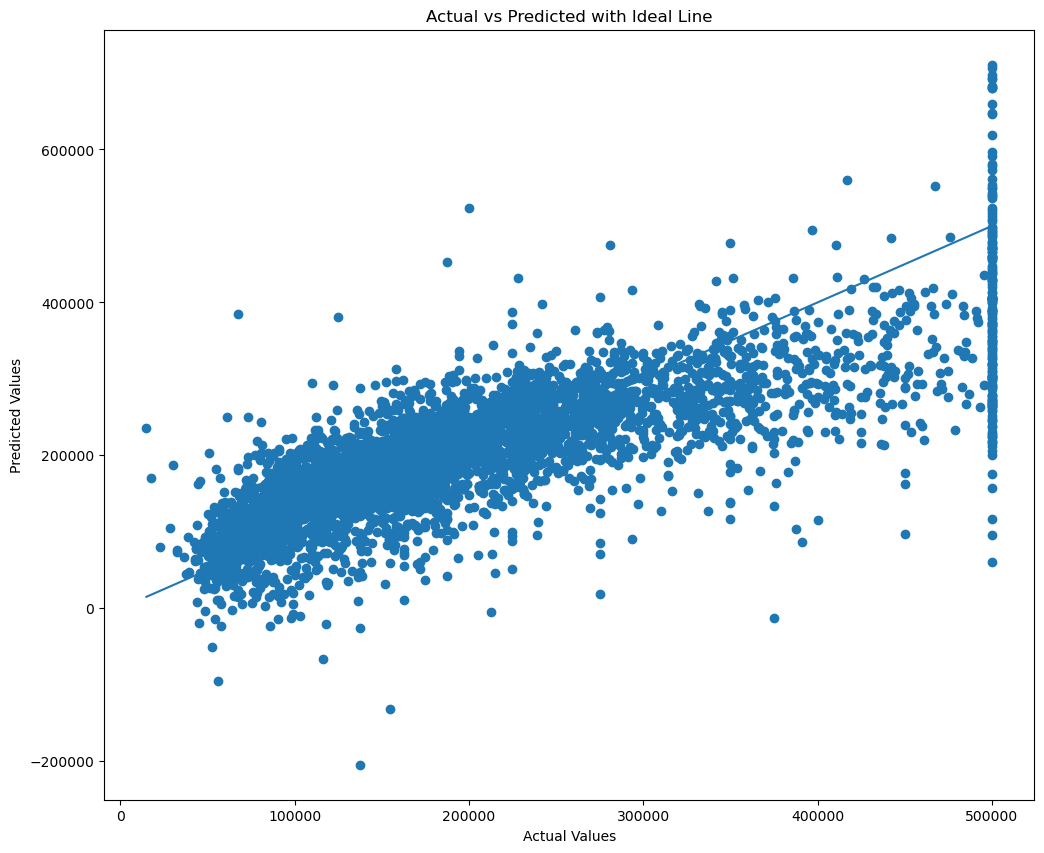


Coefficient: [ 77163.12851911  14977.03251964  47760.04560207 -17550.04812244
 -43669.4060387   18286.99412889 -89906.36314787 -84702.73463807]
Intercept: 207194.69373788778

Mean Squared Error: 5048467701.236028
R^2 Score: 0.6147410628998347


In [1]:
import numpy as np  
import pandas as pd  
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

data = pd.read_csv(r"C:\Users\manee\Downloads\housing.csv")
data.columns = data.columns.str.strip()
data.fillna(data.mean(numeric_only=True), inplace=True)
corr = data.corr(numeric_only = True)#compute correlation matrix
#correlation matrix
fig, ax = plt.subplots()
cax = ax.matshow(corr)
fig.colorbar(cax)
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
plt.title("Correlation Heatmap", pad=20)
plt.show()

#Select features (MedInc, HouseAge, AveRooms, AveBedrms, Population,
#AveOccup, Latitude, Longitude) and target (MedHouseVal).
X = data[['median_income', 'housing_median_age', 'total_bedrooms', 'total_rooms', 'population', 'households', 'latitude', 'longitude']]
y = data['median_house_value']
print("Sample Data:\n", X.head())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

alphas = [0.01, 0.1, 1, 10, 100, 1000]
model = Ridge(alpha = 10)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

plt.figure(figsize=(12, 10))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted with Ideal Line")
plt.show()

print(f"\nCoefficient: {model.coef_}")
print(f"Intercept: {model.intercept_}")

mse = mean_squared_error(y_test, y_pred)  
r2 = r2_score(y_test, y_pred)  
print(f"\nMean Squared Error: {mse}")  
print(f"R^2 Score: {r2}") 